# Finance: Can We Cut Default Losses Without Rejecting Too Many Good Borrowers?

**Business question:** using a borrower's credit history, can a lender set a smarter approval
cutoff that reduces default losses without turning away too many borrowers who would have
repaid?

**A note on the data:** this project was originally planned around Kaggle's American Express
Default Prediction competition. That dataset is 16 to 50GB and gated behind Kaggle competition
rules that need a logged in account, so it could not be used here. Instead this project uses
[Give Me Some Credit](https://www.kaggle.com/c/GiveMeSomeCredit), a smaller, older Kaggle credit
risk dataset with 150,000 borrowers and features that are all human readable, rather than
American Express's roughly 190 anonymised columns. See
[`sql/00_setup.md`](../sql/00_setup.md) for the full explanation and how the data was loaded.

## Setup

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve

from portfolio import PALETTE, apply_house_style
from portfolio.paths import project_dir

apply_house_style()
pd.set_option("display.max_columns", None)

PROJECT = project_dir("04-finance-credit-risk")
SQL = PROJECT / "sql"
FIG = PROJECT / "outputs/figures"

con = duckdb.connect(str(PROJECT / "data/processed/credit_risk.duckdb"))

def run(sql_file, index=0):
    statements = [s.strip() for s in (SQL / sql_file).read_text().split(";") if s.strip()]
    return con.execute(statements[index]).fetchdf()

## 1. Data overview

150,000 borrowers, one row per borrower, from Give Me Some Credit's training file. The target,
`serious_delinquency`, marks a borrower who went 90 or more days past due, or worse, within
two years of the record being taken.

In [2]:
run("01_data_overview.sql")

,borrowers,serious_delinquencies,default_rate_pct,missing_income,missing_dependents
0,150000,10026.0,6.68,29731,3924


**Finding:** 10,026 of 150,000 borrowers, 6.68%, had a serious delinquency. That is the
baseline rate a lender is trying to price for and reduce. Monthly income is missing for
about 20% of borrowers and number of dependents for about 2.6%, both handled in section 6.

## 2. Data quality issues worth fixing before modelling

In [3]:
run("02_data_quality_issues.sql", 0)

,age_zero_rows
0,1


In [4]:
run("02_data_quality_issues.sql", 1)

,late_30_59_sentinel_rows,late_60_89_sentinel_rows,late_90_plus_sentinel_rows,borrowers_affected
0,269,269,269,269


In [5]:
run("02_data_quality_issues.sql", 2)

,utilization_over_2,max_utilization
0,371,50708.0


In [6]:
run("02_data_quality_issues.sql", 3)

,debt_ratio_over_10,max_debt_ratio
0,28877,329664.0


**Finding:** four issues are worth handling before any model is trained, all small enough
in row count that fixing them will not bias the analysis, but large enough in scale that
leaving them in would distort it. One borrower is recorded as age 0. 269 borrowers have a 96 or
98 recorded against a late payment count, a known data entry pattern in this dataset rather than
a borrower genuinely late 96 separate times. 371 borrowers show revolving utilization above 200%
of their limit, up to a maximum of 50,708, clearly not a real utilization ratio. And 28,877
borrowers have a debt ratio above 10, with a maximum of 329,664, which happens when monthly
income is very small or zero and the ratio's denominator collapses. Section 6 caps these values
rather than dropping the borrowers entirely, so no one is thrown out of the analysis, but no
single data entry error can dominate the model either.

## 3. Does late payment history predict a future serious delinquency?

In [7]:
hist = run("03_delinquency_history.sql")
hist

,times_90_plus_days_late,borrowers,defaults,default_rate_pct
0,0 times,141662,6554.0,4.63
1,1 time,5243,1765.0,33.66
2,2 times,1555,776.0,49.90
3,3+ times,1271,784.0,61.68


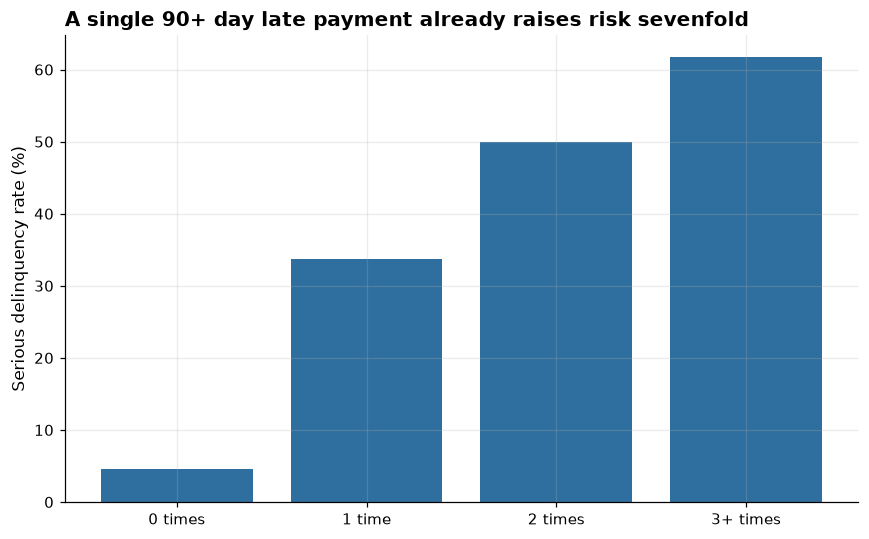

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(hist["times_90_plus_days_late"], hist["default_rate_pct"], color=PALETTE[0])
ax.set_ylabel("Serious delinquency rate (%)")
ax.set_title("A single 90+ day late payment already raises risk sevenfold")
fig.tight_layout()
fig.savefig(FIG / "01_delinquency_history.png")
plt.show()

**Finding:** borrowers with no 90+ day late payment on record default 4.63% of the time.
One such late payment already raises that to 33.66%, roughly seven times higher. Two or more
push it past 50%. This is the single strongest pattern in the data and the clearest case for
why a lender should be pricing and underwriting on payment history, not just current income.

## 4. Age and credit utilization

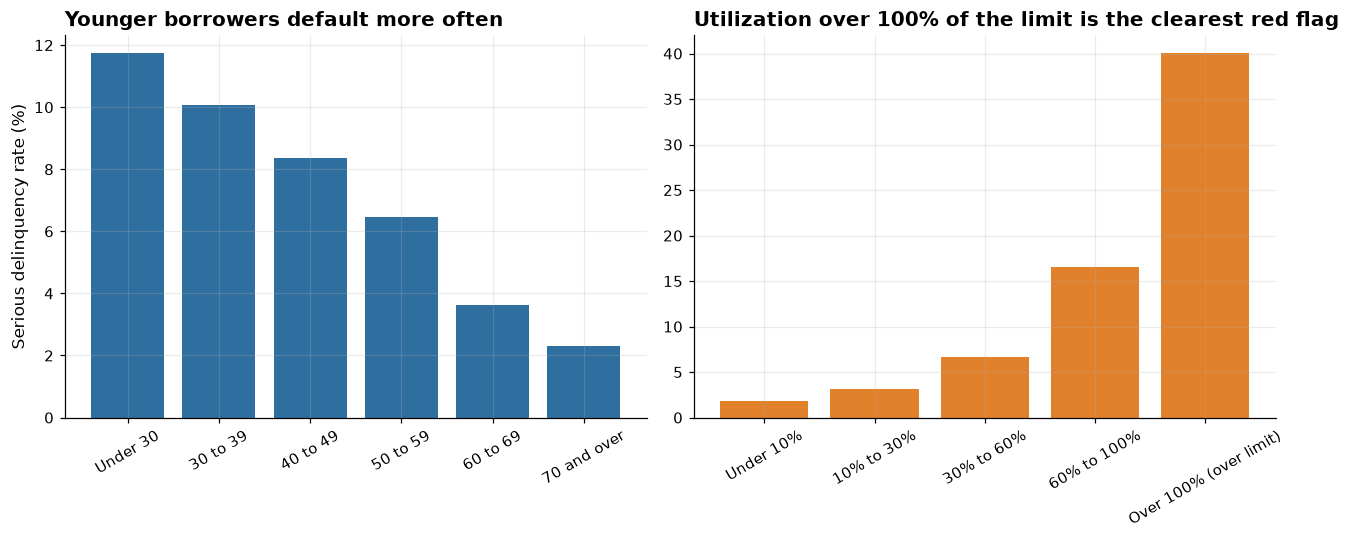

In [9]:
age = run("04_age_and_utilization.sql", 0)
util = run("04_age_and_utilization.sql", 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(age["age_band"], age["default_rate_pct"], color=PALETTE[0])
axes[0].set_title("Younger borrowers default more often")
axes[0].set_ylabel("Serious delinquency rate (%)")
axes[0].tick_params(axis="x", rotation=30)
axes[1].bar(util["utilization_band"], util["default_rate_pct"], color=PALETTE[1])
axes[1].set_title("Utilization over 100% of the limit is the clearest red flag")
axes[1].tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIG / "02_age_and_utilization.png")
plt.show()

**Finding:** default rate falls steadily with age, from 11.73% under 30 to 2.32% at 70 and
over, a plausible income-and-tenure effect rather than anything to act on directly. Utilization
is the sharper signal: borrowers using under 10% of their available revolving credit default
1.81% of the time, rising to 16.50% at 60 to 100% utilization, and 40.01% for anyone already
over their limit. A borrower maxed out on revolving credit is, on this data, roughly 22 times
more likely to have a serious delinquency than one using a small share of their limit.

## 5. Is missing income itself a risk signal?

In [10]:
run("05_missing_income.sql")

,income_status,borrowers,default_rate_pct
0,Income missing,29731,5.61
1,Income recorded,120269,6.95


**Finding:** no. Borrowers with no income recorded actually default slightly less often,
5.61%, than borrowers with income recorded, 6.95%. That rules out the natural worry that missing
income means something is being hidden. It is treated as an ordinary missing value in section 6,
filled with the median and flagged with its own indicator column so the model can still use the
fact that it was missing if that turns out to matter once combined with other features.

## 6. Building a risk score

A logistic regression is used here rather than a more complex model on purpose: a lender's risk
and compliance team need to see and explain why a given borrower was declined, and a logistic
regression's coefficients translate directly into "this factor raised or lowered the score by
this much," which a black box model does not give for free. The data quality fixes from section 2
are applied first: the one age 0 row is dropped, the 96/98 late payment sentinel values and the
most extreme utilization and debt ratio values are capped rather than deleted, and missing income
and dependents are filled with the median and 0 respectively, with a missing-income flag added
as its own feature.

In [11]:
df = con.execute("SELECT * FROM borrowers").fetchdf()

df = df[df["age"] > 0].copy()
for col in ["late_30_59_days", "late_60_89_days", "late_90_plus_days"]:
    df[col] = df[col].clip(upper=5)
df["debt_ratio"] = df["debt_ratio"].clip(upper=10)
df["revolving_utilization"] = df["revolving_utilization"].clip(upper=2)
df["income_missing"] = df["monthly_income"].isna().astype(int)
df["monthly_income"] = df["monthly_income"].fillna(df["monthly_income"].median())
df["dependents"] = df["dependents"].fillna(0)

FEATURES = [
    "revolving_utilization", "age", "late_30_59_days", "debt_ratio", "monthly_income",
    "open_credit_lines", "late_90_plus_days", "real_estate_loans", "late_60_89_days",
    "dependents", "income_missing",
]
X = df[FEATURES]
y = df["serious_delinquency"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, probs)
print(f"Test set: {len(y_test):,} borrowers, AUC = {auc:.3f}")

Test set: 45,000 borrowers, AUC = 0.852


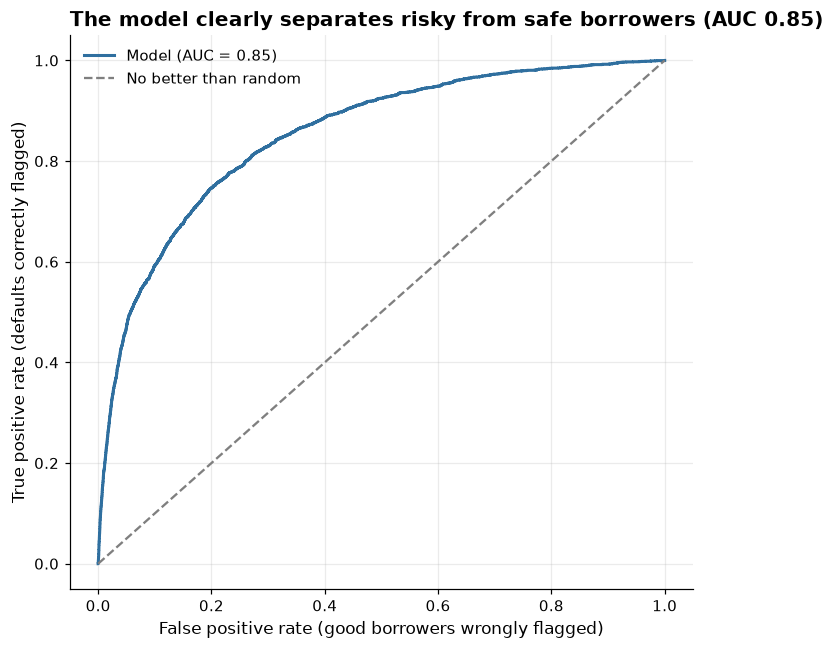

In [12]:
fpr, tpr, _ = roc_curve(y_test, probs)
fig, ax = plt.subplots(figsize=(6.5, 6))
ax.plot(fpr, tpr, color=PALETTE[0], linewidth=2, label=f"Model (AUC = {auc:.2f})")
ax.plot([0, 1], [0, 1], color=PALETTE[5], linestyle="--", label="No better than random")
ax.set_xlabel("False positive rate (good borrowers wrongly flagged)")
ax.set_ylabel("True positive rate (defaults correctly flagged)")
ax.set_title("The model clearly separates risky from safe borrowers (AUC 0.85)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "03_roc_curve.png")
plt.show()

**Finding:** an AUC of 0.85 means that, given a random defaulting borrower and a random
non-defaulting borrower, the model ranks the defaulter as riskier 85% of the time. That is a
strong result for a model built from only 10 features and is well within the range that makes a
cutoff-based decision genuinely useful, not just theoretically interesting.

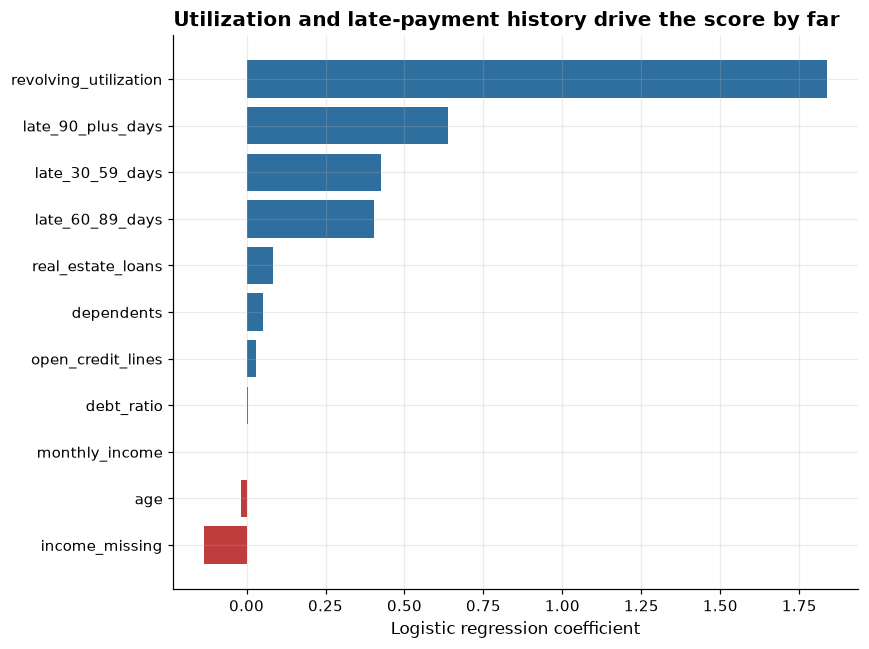

In [13]:
coefs = pd.Series(model.coef_[0], index=FEATURES).sort_values()
fig, ax = plt.subplots(figsize=(8, 6))
colors = [PALETTE[3] if c < 0 else PALETTE[0] for c in coefs]
ax.barh(coefs.index, coefs.values, color=colors)
ax.set_xlabel("Logistic regression coefficient")
ax.set_title("Utilization and late-payment history drive the score by far")
fig.tight_layout()
fig.savefig(FIG / "04_model_coefficients.png")
plt.show()

**Finding:** revolving utilization has by far the largest coefficient, consistent with
section 4, followed by the three late payment history features, consistent with section 3. Age
and debt ratio pull the score down slightly for older, lower-ratio borrowers. Monthly income and
dependents have almost no independent effect once utilization and payment history are already in
the model, a useful finding in its own right: income alone is a weak predictor, behaviour is a
strong one.

## 7. Setting the cutoff as a business decision, not a statistics exercise

A model score is not a decision by itself, a lender still has to choose a cutoff: reject anyone
scored above it, approve everyone else. Move the cutoff down and more defaults get caught, but
more good, profitable borrowers get rejected too. Move it up and the reverse happens. The right
answer depends on what a default actually costs the lender versus what a good borrower is worth,
so this section prices that trade-off directly rather than optimising a statistical metric in
isolation.

The two dollar assumptions below are illustrative, not sourced from a real lender's books, and
are exactly the kind of number a credit risk team would plug in from their own portfolio data.
They are kept in one place so they are easy to change, and the accompanying Excel workbook
(`outputs/dashboards/cutoff_scenario_model.xlsx`) lets anyone flex them without touching Python.

In [14]:
PROFIT_PER_GOOD_BORROWER = 300   # average interest margin earned over the life of the credit line
LOSS_PER_DEFAULT = 2500          # average amount lost when a borrower seriously defaults

baseline_good = int((y_test == 0).sum())
baseline_bad = int((y_test == 1).sum())
baseline_net = baseline_good * PROFIT_PER_GOOD_BORROWER - baseline_bad * LOSS_PER_DEFAULT

rows = [dict(
    threshold=0.0, policy="Approve everyone (no model)", n_approved=len(y_test),
    good_approved=baseline_good, bad_approved=baseline_bad, good_rejected=0, bad_rejected=0,
    pct_defaults_caught=0.0, pct_good_rejected=0.0, net_value=baseline_net,
)]

for thresh in [0.02, 0.05, 0.08, 0.10, 0.12, 0.15, 0.20, 0.30, 0.50]:
    reject = probs >= thresh
    approve = ~reject
    good_approved = int((approve & (y_test == 0)).sum())
    bad_approved = int((approve & (y_test == 1)).sum())
    good_rejected = int((reject & (y_test == 0)).sum())
    bad_rejected = int((reject & (y_test == 1)).sum())
    net = good_approved * PROFIT_PER_GOOD_BORROWER - bad_approved * LOSS_PER_DEFAULT
    rows.append(dict(
        threshold=thresh, policy=f"Reject if risk >= {thresh:.0%}", n_approved=int(approve.sum()),
        good_approved=good_approved, bad_approved=bad_approved,
        good_rejected=good_rejected, bad_rejected=bad_rejected,
        pct_defaults_caught=round(100 * bad_rejected / baseline_bad, 1),
        pct_good_rejected=round(100 * good_rejected / baseline_good, 1),
        net_value=net,
    ))

cutoffs = pd.DataFrame(rows)
cutoffs["net_value_vs_baseline"] = cutoffs["net_value"] - baseline_net
cutoffs

,threshold,policy,n_approved,good_approved,bad_approved,good_rejected,bad_rejected,pct_defaults_caught,pct_good_rejected,net_value,net_value_vs_baseline
0,0.00,Approve everyone (no model),45000,41992,3008,0,0,0.0,0.0,5077600,0
1,0.02,Reject if risk >= 2%,12950,12865,85,29127,2923,97.2,69.4,3647000,-1430600
2,0.05,Reject if risk >= 5%,30533,29994,539,11998,2469,82.1,28.6,7650700,2573100
3,0.08,Reject if risk >= 8%,35723,34843,880,7149,2128,70.7,17.0,8252900,3175300
4,0.10,Reject if risk >= 10%,37865,36778,1087,5214,1921,63.9,12.4,8315900,3238300
5,0.12,Reject if risk >= 12%,39527,38224,1303,3768,1705,56.7,9.0,8209700,3132100
6,0.15,Reject if risk >= 15%,41185,39667,1518,2325,1490,49.5,5.5,8105100,3027500
7,0.20,Reject if risk >= 20%,42380,40546,1834,1446,1174,39.0,3.4,7578800,2501200
8,0.30,Reject if risk >= 30%,43370,41192,2178,800,830,27.6,1.9,6912600,1835000
9,0.50,Reject if risk >= 50%,44233,41676,2557,316,451,15.0,0.8,6110300,1032700


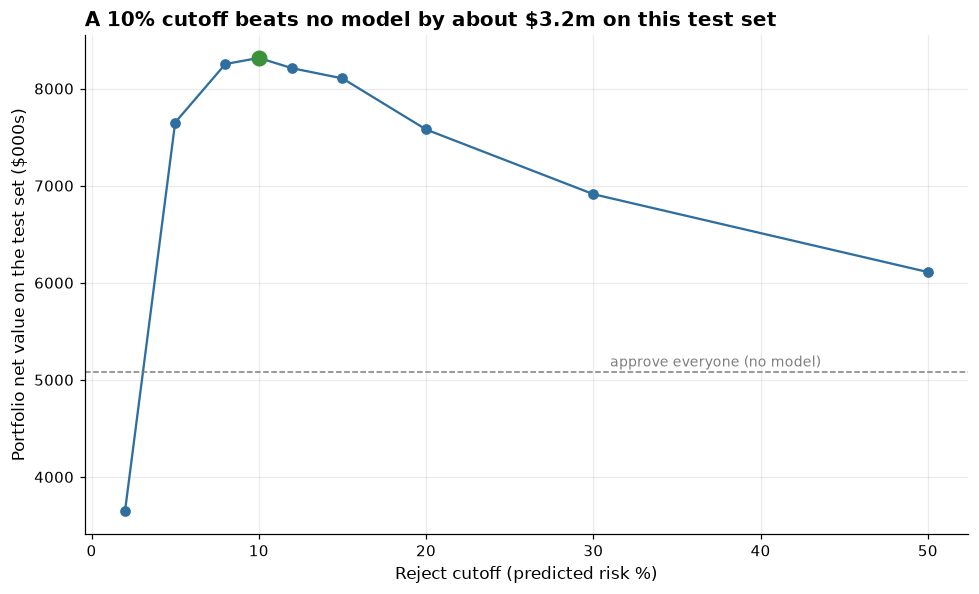

In [15]:
fig, ax = plt.subplots(figsize=(9, 5.5))
plot_df = cutoffs[cutoffs["threshold"] > 0]
ax.plot(plot_df["threshold"] * 100, plot_df["net_value"] / 1000, marker="o", color=PALETTE[0])
ax.axhline(baseline_net / 1000, color=PALETTE[5], linestyle="--", linewidth=1)
ax.text(31, baseline_net / 1000 + 60, "approve everyone (no model)", fontsize=9, color=PALETTE[5])
best_row = plot_df.loc[plot_df["net_value"].idxmax()]
ax.scatter([best_row["threshold"] * 100], [best_row["net_value"] / 1000], color=PALETTE[2], s=90, zorder=5)
ax.set_xlabel("Reject cutoff (predicted risk %)")
ax.set_ylabel("Portfolio net value on the test set ($000s)")
ax.set_title(f"A {best_row['threshold']:.0%} cutoff beats no model by about ${best_row['net_value_vs_baseline']/1e6:.1f}m on this test set")
fig.tight_layout()
fig.savefig(FIG / "05_cutoff_scenario.png")
plt.show()

**Finding:** under these cost assumptions, the best cutoff on this test set is 10%,
rejecting anyone the model scores at 10% or higher risk of serious delinquency. That single
change catches 63.9% of the defaults that would otherwise slip through, while rejecting only
12.4% of the borrowers who would actually have been fine, and lifts the portfolio's net value by
roughly $3.2 million on this 45,000-borrower test set compared with approving everyone. The
curve also shows why being more aggressive is not automatically better: a 2% cutoff catches
almost every default, 97.2%, but rejects 69.4% of good borrowers along with them, and actually
destroys more value than it saves, because so many profitable borrowers are turned away in the
process. The right cutoff sits where the two costs balance, not at either extreme.

## 8. Limitations

The two dollar figures behind section 7, profit per good borrower and loss per default, are
illustrative assumptions rather than figures from a real lender's books, so the exact
recommended cutoff, 10%, will shift once real portfolio economics are used in their place. That
is by design: the Excel scenario model makes those two numbers the only inputs that need
changing to get a new recommended cutoff, everything else recalculates from there. The model
itself is a single, fairly simple logistic regression trained on one static snapshot of
150,000 borrowers with no macroeconomic context, so it should be treated as a first, explainable
pass at the problem, not a production-ready underwriting model, and would need to be retrained
and monitored over time in a real deployment. Finally, this dataset predates recent consumer
credit reporting standards and fair lending checks a real deployment would need, including a
formal review for whether any input, directly or indirectly, produces unequal outcomes across
protected groups; none of that review has been done here.

## Summary

See [`report.md`](../report.md) for the full written analysis, and [`README.md`](../README.md)
for the one-page version. The Excel scenario model with adjustable cost assumptions is at
[`outputs/dashboards/cutoff_scenario_model.xlsx`](../outputs/dashboards/cutoff_scenario_model.xlsx).